Import Libraries


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

Load Dataset

In [5]:
df=pd.read_csv('ss.csv' , encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Dataset Information


In [6]:
print("Shape:", df.shape)

df.info()

Shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

Missing Values


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicate Records

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Remove Duplicates

In [9]:
df = df.drop_duplicates()

print(df.shape)

(9994, 21)


Statistical summary

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Dataset Columns

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Convert Date Column

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month_name()

Total Sales KPI

In [13]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales,2))

Total Sales: 2297200.86


Total Profit KPI

In [14]:
total_profit = df["Profit"].sum()

print("Total Profit:", round(total_profit,2))

Total Profit: 286397.02


Total Orders KPI`

In [15]:
print("Total Orders:", df["Order ID"].nunique())

Total Orders: 5009


Total Customers KPI

In [16]:
print("Total Customers:", df["Customer ID"].nunique())

Total Customers: 793


Sales by Category

In [17]:
category_sales = df.groupby(
    "Category"
)["Sales"].sum().sort_values(
    ascending=False
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


Category Sales Chart

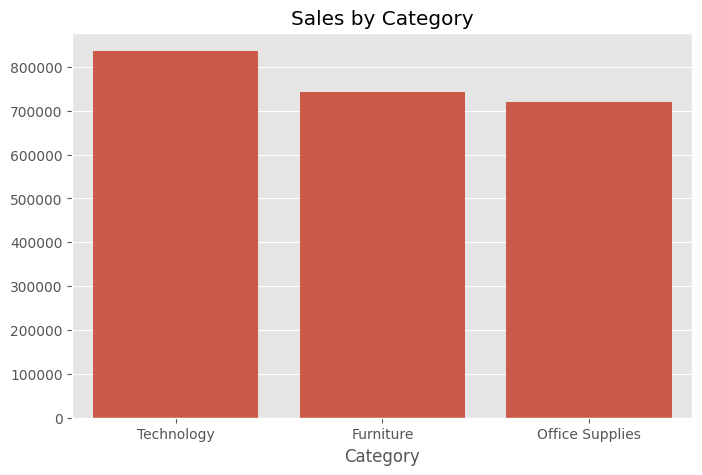

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")

plt.show()

Profit by Category

In [19]:
profit_category = df.groupby(
    "Category"
)["Profit"].sum()

profit_category

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


Top 10 Products

In [37]:
top_products = df.groupby(
    "Product Name"
)["Sales"].sum().sort_values(
    ascending = False
).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


Top Product Charts


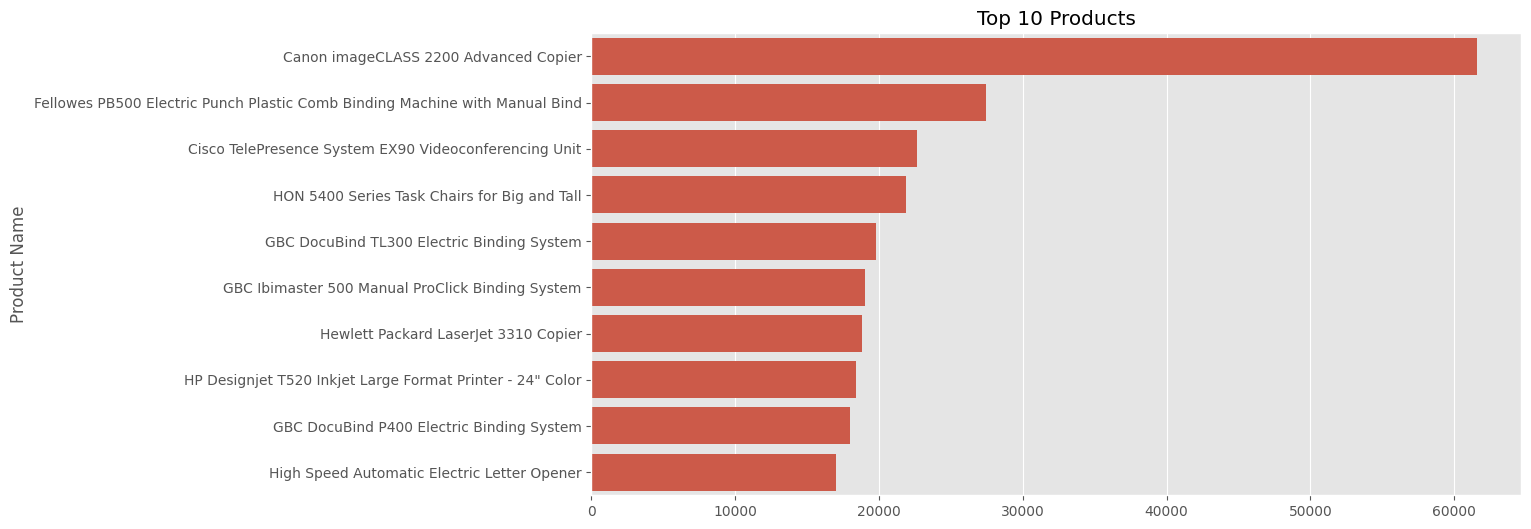

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products")

plt.show()

Sales by region

In [22]:
region_sales = df.groupby(
    "Region"
)["Sales"].sum()

region_sales

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


Region chart

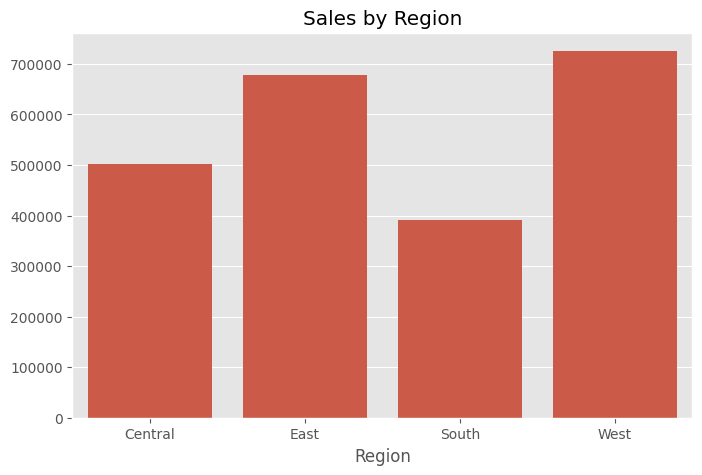

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")

plt.show()

Profit by Region

In [24]:
region_profit = df.groupby(
    "Region"
)["Profit"].sum()

region_profit

,Profit
Region,
Central,39706.3625
East,91522.7800
South,46749.4303
West,108418.4489


Monthly Sales Trend

In [25]:
monthly_sales = df.groupby(
    "Month"
)["Sales"].sum()

monthly_sales

,Sales
Month,
April,137762.1286
August,159044.0630
December,325293.5035
February,59751.2514
January,94924.8356
July,147238.0970
June,152718.6793
March,205005.4888
May,155028.8117


Monthly Sales plot

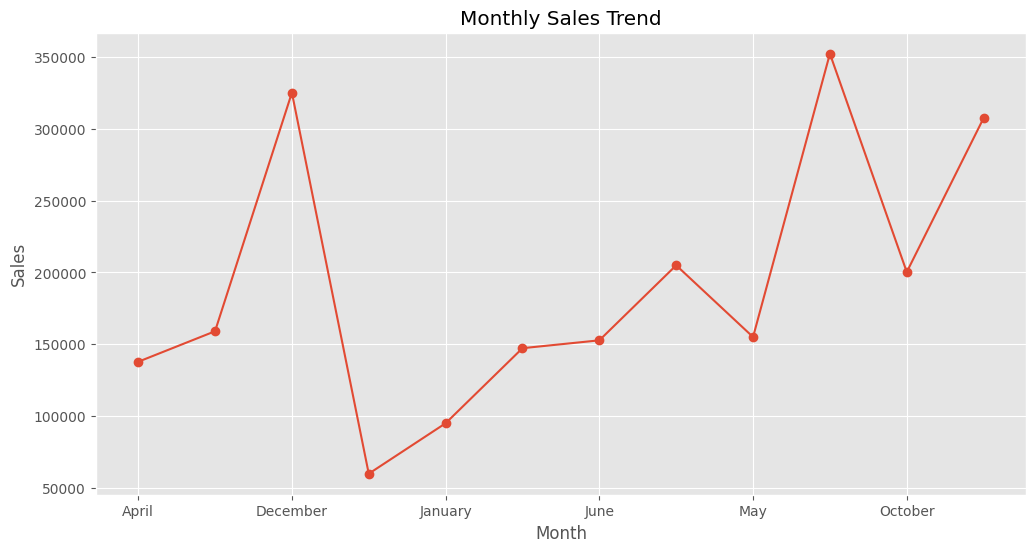

In [26]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

Top Customers

In [27]:
top_customers = df.groupby(
    "Customer Name"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


Customer Chart

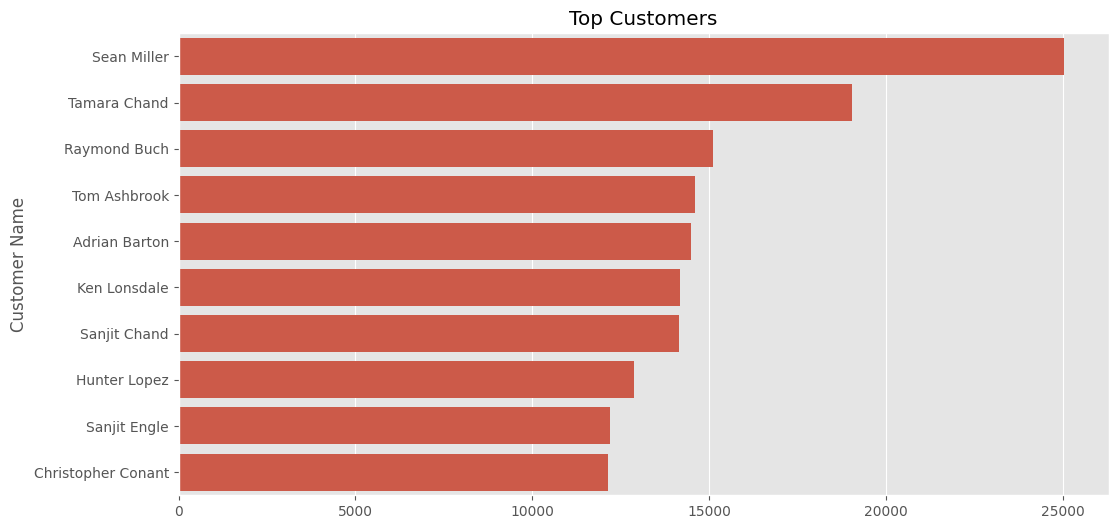

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top Customers")

plt.show()

Correlation Analysis

In [29]:
numeric_df = df.select_dtypes(
    include=np.number
)

numeric_df.corr()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497,0.015430
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961,0.004299
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064,-0.009679
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253,-0.005810
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487,-0.002662
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000,0.004670
Year,0.015430,0.004299,-0.009679,-0.005810,-0.002662,0.004670,1.000000


Heatmap

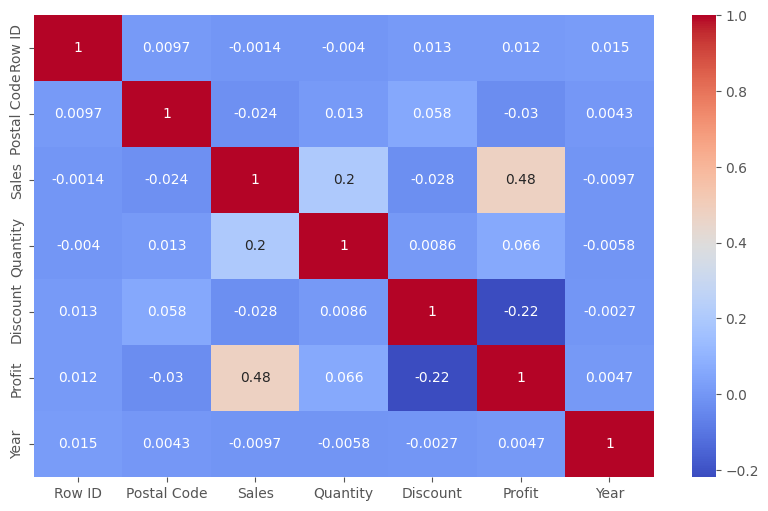

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Business Insights

In [31]:
print("""
BUSINESS INSIGHTS

1. Identify highest revenue category.

2. Identify most profitable region.

3. Find top 10 customers.

4. Find top-selling products.

5. Analyze monthly sales trends.

6. Identify low-performing categories.

7. Understand discount-profit relationship.

""")


BUSINESS INSIGHTS

1. Identify highest revenue category.

2. Identify most profitable region.

3. Find top 10 customers.

4. Find top-selling products.

5. Analyze monthly sales trends.

6. Identify low-performing categories.

7. Understand discount-profit relationship.




Export Cleaned Dataset

In [34]:
df.to_csv(
    "ss.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
